In [42]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn import svm
from sklearn.metrics import accuracy_score

In [43]:
## Importing data 

data = pd.read_csv("Data.csv")

In [44]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [45]:
data.shape

(614, 13)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [47]:
print(data.Gender.value_counts())
print(data.Married.value_counts())
print(data.Dependents.value_counts())
print(data.Education.value_counts())
print(data.Self_Employed.value_counts())
print(data.Property_Area.value_counts())
print(data.Loan_Status.value_counts())


Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [48]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [49]:
data = data.dropna()

In [50]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [51]:
print(data.Gender.value_counts())
print(data.Married.value_counts())
print(data.Dependents.value_counts())
print(data.Education.value_counts())
print(data.Self_Employed.value_counts())
print(data.Property_Area.value_counts())
print(data.Loan_Status.value_counts())


Gender
Male      394
Female     86
Name: count, dtype: int64
Married
Yes    311
No     169
Name: count, dtype: int64
Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64
Education
Graduate        383
Not Graduate     97
Name: count, dtype: int64
Self_Employed
No     414
Yes     66
Name: count, dtype: int64
Property_Area
Semiurban    191
Urban        150
Rural        139
Name: count, dtype: int64
Loan_Status
Y    332
N    148
Name: count, dtype: int64


In [52]:
# Data encoding

data.replace({'Gender': {'Male': 0, 'Female': 1}}, inplace=True)
data.replace({'Married': {'Yes': 1, 'No': 0}}, inplace=True)
data.replace({'Loan_Status': {'N': 0, 'Y': 1}}, inplace=True)
data.replace({'Self_Employed': {'No': 0, 'Yes': 1}}, inplace=True)
data.replace({'Property_Area': {'Rural': 0, 'Semiurban': 1, 'Urban': 2}}, inplace=True)
data.replace({'Education': {'Graduate': 0, 'Not Graduate': 1}}, inplace=True)

# Dependents column
data['Dependents'] = data['Dependents'].replace('3+', 4).astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_6320\3981079565.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Gender': {'Male': 0, 'Female': 1}}, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_6320\3981079565.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Married': {'Yes': 1, 'No': 0}}, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_6320\3981079565.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavio

In [53]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,0,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,0,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,1,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,LP002979,0,1,4,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,LP002983,0,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,LP002984,0,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


<Axes: xlabel='Education', ylabel='count'>

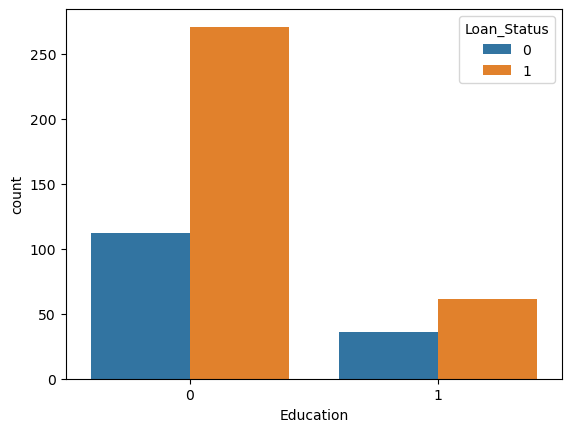

In [54]:
sns.countplot(x='Education',hue='Loan_Status',data = data)

In [55]:
## Separatig data and label 
X = data.drop(columns=["Loan_Status","Loan_ID"])
Y = data["Loan_Status"]

In [56]:
print(X.shape)
print(Y.shape)

(480, 11)
(480,)


In [57]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,0,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,0,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,0,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,0,0,0,0,0,6000,0.0,141.0,360.0,1.0,2
5,0,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,1,0,0,0,0,2900,0.0,71.0,360.0,1.0,0
610,0,1,4,0,0,4106,0.0,40.0,180.0,1.0,0
611,0,1,1,0,0,8072,240.0,253.0,360.0,1.0,2
612,0,1,2,0,0,7583,0.0,187.0,360.0,1.0,2


In [58]:
Y

1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 480, dtype: int64

In [59]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.1,random_state=42)
for train_index,test_index in split.split(X,Y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    Y_train = Y.iloc[train_index]
    Y_test = Y.iloc[test_index]

In [60]:
model = svm.SVC(kernel='linear')

In [61]:
model.fit(X_train,Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
## Train prediction and score

Train_pred = model.predict(X_train)

Train_score = accuracy_score(Train_pred,Y_train)

Train_score

0.7824074074074074

In [64]:
## Test prediction and score

Test_pred = model.predict(X_test)

Test_score = accuracy_score(Test_pred,Y_test)

Test_score

0.7708333333333334

In [65]:
## Making a predictive system

input_data = [0,	1,	1,	0,	0,	4583	,1508.0,	128.0,	360.0,	1.0,	0]

# Input data as np array
input_data_as_np_aray = np.asarray(input_data)

# Reshaping the data

input_data_reshaped = input_data_as_np_aray.reshape(1,-1)

# Prediction of model
Prediction = model.predict(input_data_reshaped)

if Prediction[0] == 1:
    print("You are eligible for taking a loan ")
else:
    print("You are not eligible for the Loan")

You are eligible for taking a loan 


d:\HP\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
